### Generate flux samples

Uses Flux.2-klein-4B as a text to image model to generate a dataset of training blocks for flow distillation.

Each block is 
* Initial noise latents $x_1$
* Final generated latents just before decoding $x_0$
* Downsampled $x_0$ through decode -> downsample -> encode $c$

During generation we will need some various random prompts. To generate them we will use COCO 2017 captions with random style modifiers.

In [1]:
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig
import torch
import time
import torch
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel
import numpy as np
import random
from tqdm import tqdm
import json

import matplotlib.pyplot as plt
from diffusers.utils import load_image

device = "cuda"
plt.style.use("dark_background")

In [2]:
dtype = torch.bfloat16

text_encoder = Qwen3ForCausalLM.from_pretrained(
    "../../FLUX.2-klein-4B/text_encoder", local_files_only=True
).to(device)
tokenizer = Qwen2TokenizerFast.from_pretrained(
    "../../FLUX.2-klein-4B/tokenizer", local_files_only=True, device=device
)

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "../../FLUX.2-klein-4B/scheduler", device=device
)
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(
    device, dtype
)
transformer = Flux2Transformer2DModel.from_pretrained(
    "../../FLUX.2-klein-4B/transformer", device=device
).to(device, dtype)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
def _get_qwen3_prompt_embeds(
    text_encoder: Qwen3ForCausalLM,
    tokenizer: Qwen2TokenizerFast,
    prompt: str | list[str],
    dtype: torch.dtype | None = None,
    device: torch.device | None = None,
    max_sequence_length: int = 512,
    hidden_states_layers: list[int] = (9, 18, 27),
):
    dtype = text_encoder.dtype if dtype is None else dtype
    device = text_encoder.device if device is None else device

    prompt = [prompt] if isinstance(prompt, str) else prompt

    all_input_ids = []
    all_attention_masks = []

    for single_prompt in prompt:
        messages = [{"role": "user", "content": single_prompt}]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        inputs = tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=max_sequence_length,
        )

        all_input_ids.append(inputs["input_ids"])
        all_attention_masks.append(inputs["attention_mask"])

    input_ids = torch.cat(all_input_ids, dim=0).to(device)
    attention_mask = torch.cat(all_attention_masks, dim=0).to(device)

    # Forward pass through the model
    output = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )

    # Only use outputs from intermediate layers and stack them
    out = torch.stack([output.hidden_states[k] for k in hidden_states_layers], dim=1)
    out = out.to(dtype=dtype, device=device)

    batch_size, num_channels, seq_len, hidden_dim = out.shape
    prompt_embeds = out.permute(0, 2, 1, 3).reshape(
        batch_size, seq_len, num_channels * hidden_dim
    )

    return prompt_embeds


def _prepare_text_ids(
    x: torch.Tensor,  # (B, L, D) or (L, D)
    t_coord: torch.Tensor | None = None,
):
    B, L, _ = x.shape
    out_ids = []

    for i in range(B):
        t = torch.arange(1) if t_coord is None else t_coord[i]
        h = torch.arange(1)
        w = torch.arange(1)
        l = torch.arange(L)

        coords = torch.cartesian_prod(t, h, w, l)
        out_ids.append(coords)

    return torch.stack(out_ids)


@torch.no_grad()
def encode_prompt(
    prompt: str | list[str],
    device: torch.device | None = None,
    num_images_per_prompt: int = 1,
    prompt_embeds: torch.Tensor | None = None,
    max_sequence_length: int = 512,
    text_encoder_out_layers: tuple[int] = (9, 18, 27),
):
    prompt = [prompt] if isinstance(prompt, str) else prompt

    prompt_embeds = _get_qwen3_prompt_embeds(
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_sequence_length=max_sequence_length,
        hidden_states_layers=text_encoder_out_layers,
    )

    batch_size, seq_len, _ = prompt_embeds.shape
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(batch_size * num_images_per_prompt, seq_len, -1)

    text_ids = _prepare_text_ids(prompt_embeds)
    text_ids = text_ids.to(device)
    return prompt_embeds, text_ids

In [4]:
def _prepare_latent_ids(
    latents: torch.Tensor,  # (B, C, H, W)
):
    r"""
    Generates 4D position coordinates (T, H, W, L) for latent tensors.

    Args:
        latents (torch.Tensor):
            Latent tensor of shape (B, C, H, W)

    Returns:
        torch.Tensor:
            Position IDs tensor of shape (B, H*W, 4) All batches share the same coordinate structure: T=0,
            H=[0..H-1], W=[0..W-1], L=0
    """

    batch_size, _, height, width = latents.shape

    t = torch.arange(1)  # [0] - time dimension
    h = torch.arange(height)
    w = torch.arange(width)
    l = torch.arange(1)  # [0] - layer dimension

    # Create position IDs: (H*W, 4)
    latent_ids = torch.cartesian_prod(t, h, w, l)

    # Expand to batch: (B, H*W, 4)
    latent_ids = latent_ids.unsqueeze(0).expand(batch_size, -1, -1)

    return latent_ids


def _patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents


def _unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents


def _pack_latents(latents):
    """
    pack latents: (batch_size, num_channels, height, width) -> (batch_size, height * width, num_channels)
    """

    batch_size, num_channels, height, width = latents.shape
    latents = latents.reshape(batch_size, num_channels, height * width).permute(0, 2, 1)

    return latents


def _unpack_latents_with_ids(
    x: torch.Tensor,
    x_ids: torch.Tensor,
    height: int | None = None,
    width: int | None = None,
) -> list[torch.Tensor]:
    """
    using position ids to scatter tokens into place
    """
    x_list = []
    for data, pos in zip(x, x_ids):
        _, ch = data.shape  # noqa: F841
        h_ids = pos[:, 1].to(torch.int64)
        w_ids = pos[:, 2].to(torch.int64)

        # Use provided height/width to avoid DtoH sync from torch.max().item()
        h = height if height is not None else torch.max(h_ids) + 1
        w = width if width is not None else torch.max(w_ids) + 1

        flat_ids = h_ids * w + w_ids

        out = torch.zeros((h * w, ch), device=data.device, dtype=data.dtype)
        out.scatter_(0, flat_ids.unsqueeze(1).expand(-1, ch), data)

        # reshape from (H * W, C) to (H, W, C) and permute to (C, H, W)

        out = out.view(h, w, ch).permute(2, 0, 1)
        x_list.append(out)

    return torch.stack(x_list, dim=0)


def prepare_latents(
    batch_size,
    num_latents_channels,
    height,
    width,
    dtype,
    device,
    generator: torch.Generator,
):
    # VAE applies 8x compression on images but we must also account for packing which requires
    # latent height and width to be divisible by 2.

    vae_scale_factor = 8
    height = 2 * (int(height) // (vae_scale_factor * 2))
    width = 2 * (int(width) // (vae_scale_factor * 2))

    shape = (batch_size, num_latents_channels * 4, height // 2, width // 2)

    latents = torch.randn(shape, generator=generator, device=device, dtype=dtype)

    latent_ids = _prepare_latent_ids(latents)
    latent_ids = latent_ids.to(device)

    latents = _pack_latents(latents)  # [B, C, H, W] -> [B, H*W, C]
    return latents, latent_ids


latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(device, dtype)
latents_bn_std = torch.sqrt(
    vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps
).to(device, dtype)


In [5]:
def retrieve_timesteps(
    scheduler,
    num_inference_steps: int,
    device: str | torch.device,
    sigmas: list[float],
    **kwargs,
):
    scheduler.set_timesteps(sigmas=sigmas, device=device, **kwargs)
    timesteps = scheduler.timesteps
    num_inference_steps = len(timesteps)

    return timesteps, num_inference_steps


def compute_empirical_mu(image_seq_len: int, num_steps: int) -> float:
    a1, b1 = 8.73809524e-05, 1.89833333
    a2, b2 = 0.00016927, 0.45666666

    if image_seq_len > 4300:
        mu = a2 * image_seq_len + b2
        return float(mu)

    m_200 = a2 * image_seq_len + b2
    m_10 = a1 * image_seq_len + b1

    a = (m_200 - m_10) / 190.0
    b = m_200 - 200.0 * a
    mu = a * num_steps + b

    return float(mu)

In [6]:
def norm_unpatchified_latents(latents):
    latents = _patchify_latents(latents)
    latents = latents - latents_bn_mean
    latents = latents / latents_bn_std
    latents = _unpatchify_latents(latents)

    return latents


def denorm_unpatchified_latents(latents):
    latents = _patchify_latents(latents)
    latents = latents * latents_bn_std
    latents = latents + latents_bn_mean
    latents = _unpatchify_latents(latents)

    return latents


def decode_denorm_latents(latents):
    with torch.no_grad():
        image = vae.decode(latents.to(torch.bfloat16), return_dict=False)[0]

    return image


def torch_image_show(image):
    image = image.add(1).div(2)
    image = image.float()
    image = image.squeeze(0).permute(1, 2, 0)
    image = image.clip(0, 1)
    image = image.cpu().numpy()

    plt.imshow(image)
    plt.show()

In [7]:
modifiers = [
    "anime art",
    "ultra detailed",
    "hyper realism",
    "night photography",
    "bokeh",
    "cinematic light",
    "oil on canvas art in style of Kandinsky",
    "golden hour",
    "a real world photo made on handy camera",
    "art in style of cosmic fantasy anime",
    "ultra detailed professional digital art",
    "epic textures",
    "intricate linear patterns are covering everything",
    "thousands of objects, very complex scene",
    "Gzhel world, complex patterns are covering object",
    "high fashion photography style, night, neon, cyberpunk, sharp focus",
    "anime art in style of studio Ghibli",
    "grain textures",
    "4K textures, super sharp",
    "retro anime art, smooth colors, sharp details",
    "sharp focus on text, readable English characters and numbers",
    "anime",
    "manga",
    "comic book",
    "watercolor",
    "oil painting",
    "acrylic painting",
    "pastel drawing",
    "charcoal sketch",
    "ink illustration",
    "pixel art",
    "low poly art",
    "minimalist art",
    "35mm film",
    "50mm lens",
    "85mm portrait lens",
    "wide angle lens",
    "telephoto lens",
    "macro photography",
    "tilt shift photography",
    "shallow depth of field",
    "deep focus",
    "golden hour",
    "blue hour",
    "soft lighting",
    "hard lighting",
    "studio lighting",
    "cinematic lighting",
    "rim lighting",
    "backlit",
    "neon lighting",
    "candlelight",
    "moonlight",
    "dramatic shadows",
    "vibrant colors",
    "muted colors",
    "pastel colors",
    "monochrome",
    "high contrast",
    "warm tones",
    "cool tones",
    "unreal engine render",
    "octane render",
    "ray traced",
    "cinematic render",
    "medieval",
    "renaissance",
    "1980s",
    "retro futurism",
    "cyberpunk",
]

In [8]:
with open("../../coco2017/annotations/captions_train2017.json") as f:
    data = json.load(f)

base_prompts = data["annotations"]

In [9]:
def build_random_prompt():
    prompt = random.choice(base_prompts)["caption"]
    num_modifiers = random.randint(0, 3)
    for i in range(num_modifiers):
        prompt += ", " + random.choice(modifiers)

    return prompt


build_random_prompt()

'A large kitchen with two trashcans, a large gas stove, and many dishes organized and put up.'

In [ ]:
@torch.no_grad()
def generate_one_block():

    num_inference_steps = 4

    prompt = build_random_prompt()
    seed = random.randint(0, 10000000)

    prompt_embeds, text_ids = encode_prompt(
        prompt=prompt,
        device=device,
        num_images_per_prompt=1,
        max_sequence_length=512,
        text_encoder_out_layers=(9, 18, 27),
    )

    generator = torch.Generator(device="cuda").manual_seed(seed)

    height = 1024
    width = 1024

    latents, latent_ids = prepare_latents(
        batch_size=1,
        num_latents_channels=32,
        height=height,
        width=width,
        dtype=dtype,
        device=device,
        generator=generator,
    )

    sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)

    image_seq_len = latents.shape[1]

    mu = compute_empirical_mu(
        image_seq_len=image_seq_len, num_steps=num_inference_steps
    )

    timesteps, num_inference_steps = retrieve_timesteps(
        scheduler,
        num_inference_steps,
        device,
        sigmas=sigmas,
        mu=mu,
    )

    scheduler.set_begin_index(0)

    init_latents = latents.clone()
    init_latents = _unpack_latents_with_ids(init_latents, latent_ids)
    init_latents = _unpatchify_latents(init_latents)

    # init_latents -> return

    for i, t in enumerate(timesteps):
        timestep = t.expand(latents.shape[0]).to(latents.dtype)

        latent_model_input = latents.to(transformer.dtype)
        latent_image_ids = latent_ids

        noise_pred = transformer(
            hidden_states=latent_model_input,  # (B, image_seq_len, C)
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,  # B, text_seq_len, 4
            img_ids=latent_image_ids,  # B, image_seq_len, 4
            return_dict=False,
        )[0]

        noise_pred = noise_pred[:, : latents.size(1), :]

        # compute the previous noisy sample x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents, return_dict=False)[0]

    # decode

    vae_scale_factor = 8

    latent_height = 2 * (int(height) // (vae_scale_factor * 2))
    latent_width = 2 * (int(width) // (vae_scale_factor * 2))

    latents = _unpack_latents_with_ids(
        latents, latent_ids, latent_height // 2, latent_width // 2
    )

    latents_orig = _unpatchify_latents(latents)

    # latents_orig -> return

    latents = latents * latents_bn_std + latents_bn_mean
    latents = _unpatchify_latents(latents)

    image = decode_denorm_latents(latents)

    # downscale

    image_div_2 = torch.nn.functional.interpolate(
        image, size=(height // 2, width // 2), mode="bilinear", align_corners=False
    )

    # encode
    latents_div_2 = vae.encode(image_div_2).latent_dist.mean

    latents_div_2 = norm_unpatchified_latents(latents_div_2)

    # latents_div_2 -> return

    return init_latents, latents_orig, latents_div_2, prompt

torch.Size([1, 32, 128, 128]) tensor(0.0003, device='cuda:0', dtype=torch.bfloat16) tensor(1., device='cuda:0', dtype=torch.bfloat16)
torch.Size([1, 32, 128, 128]) tensor(0.0047, device='cuda:0', dtype=torch.bfloat16) tensor(1.0781, device='cuda:0', dtype=torch.bfloat16)
torch.Size([1, 32, 64, 64]) tensor(-0.0036, device='cuda:0', dtype=torch.bfloat16) tensor(1.0391, device='cuda:0', dtype=torch.bfloat16)


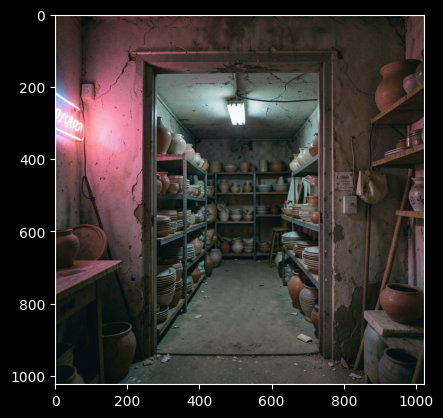

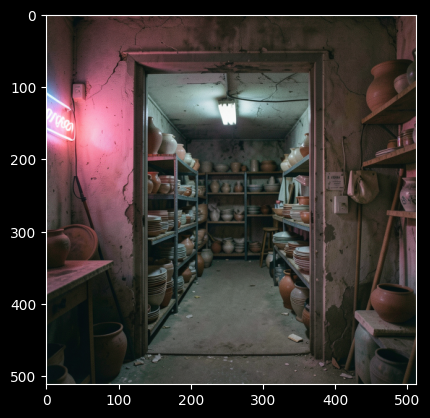

A doorway into an old storage area for pottery and dishes., epic textures, 35mm film, neon lighting


In [17]:
init_latents, latents_orig, latents_div_2, prompt = generate_one_block()
print(init_latents.shape, init_latents.mean(), init_latents.std())
print(latents_orig.shape, latents_orig.mean(), latents_orig.std())
print(latents_div_2.shape, latents_div_2.mean(), latents_div_2.std())

torch_image_show(decode_denorm_latents(denorm_unpatchified_latents(latents_orig)))
torch_image_show(decode_denorm_latents(denorm_unpatchified_latents(latents_div_2)))

print(prompt)


In [18]:
num_blocks = 100

In [19]:
height = 1024
width = 1024

latent_height = height // 8
latent_width = width // 8


all_noise = torch.zeros(
    (num_blocks, 32, latent_height, latent_width),
    dtype=torch.float16,
)

all_latents_orig = torch.zeros(
    (num_blocks, 32, latent_height, latent_width),
    dtype=torch.float16,
)

all_latents_div_2 = torch.zeros(
    (num_blocks, 32, latent_height // 2, latent_width // 2),
    dtype=torch.float16,
)

all_prompts = []

In [20]:
for i in tqdm(range(num_blocks)):
    init_latents, latents_orig, latents_div_2, prompt = generate_one_block()
    all_noise[i, ...] = init_latents.cpu()
    all_latents_orig[i, ...] = latents_orig.cpu()
    all_latents_div_2[i, ...] = latents_div_2.cpu()
    all_prompts.append(prompt)

100%|██████████| 100/100 [01:37<00:00,  1.02it/s]


In [21]:
torch.save(all_noise, "../../precomputes/flow_upscaler/noise-example.pt")
torch.save(all_latents_orig, "../../precomputes/flow_upscaler/latents_orig-example.pt")
torch.save(
    all_latents_div_2, "../../precomputes/flow_upscaler/latents_div_2-example.pt"
)

with open("../../precomputes/flow_upscaler/prompts-example.json", "w") as file:
    json.dump(all_prompts, file)